# Tutorial 06: Build a Custom RL Environment

In tutorial 04, you learned the raw GRPO algorithm -- sampling completions, grading them, computing advantages, and training. In tutorial 05, you saw how the cookbook's standard abstractions (`ProblemEnv`, `ProblemGroupBuilder`, `RLDataset`, `compute_advantages`, `assemble_training_data`) handle the boilerplate so you can focus on the task-specific logic.

Now you will implement your own custom task from scratch using those abstractions. The pattern is always the same:

1. **Subclass `ProblemEnv`** -- implement 4 methods that define your task
2. **Create an `RLDataset`** -- yields `ProblemGroupBuilder`s that wrap your env
3. **Run the standard training loop** -- rollouts, advantages, datums, train

In [ ]:
import json
import re
import warnings
from collections.abc import Sequence
from functools import partial

warnings.filterwarnings("ignore", message="IProgress not found")

import tinker  # noqa: E402

from tinker_cookbook.renderers import get_renderer, get_text_content  # noqa: E402  # noqa: I001
from tinker_cookbook.rl.data_processing import (  # noqa: E402
    assemble_training_data,
    compute_advantages,
)
from tinker_cookbook.rl.problem_env import ProblemEnv, ProblemGroupBuilder  # noqa: E402
from tinker_cookbook.rl.rollouts import do_group_rollout_and_filter_constant_reward  # noqa: E402
from tinker_cookbook.rl.types import EnvGroupBuilder, RLDataset  # noqa: E402
from tinker_cookbook.tokenizer_utils import get_tokenizer  # noqa: E402

## Step 1 -- Define the problem data

Our task: **format compliance**. Each problem gives the model a topic and a required output format (JSON, numbered list, or haiku). The reward function checks whether the model's response actually follows the requested format.

We split problems into train and eval sets.

In [2]:
# Each problem is (prompt, format_type)
TRAIN_PROBLEMS = [
    (
        "List 5 programming languages and their main use cases. Respond in JSON format with a list of objects, each having 'language' and 'use_case' keys.",
        "json",
    ),
    ("Describe the water cycle. Use a numbered list with at least 4 steps.", "numbered_list"),
    ("Write a haiku about the ocean.", "haiku"),
    (
        "Name 3 planets and one fact about each. Respond in JSON format as a list of objects with 'planet' and 'fact' keys.",
        "json",
    ),
    ("Explain how to make a sandwich. Use a numbered list.", "numbered_list"),
    ("Write a haiku about autumn leaves.", "haiku"),
    ("List 3 types of renewable energy with descriptions. Respond in JSON format.", "json"),
    ("Describe the steps to brush your teeth. Use a numbered list.", "numbered_list"),
]

EVAL_PROBLEMS = [
    (
        "Describe machine learning in JSON format with keys: definition, types, applications.",
        "json",
    ),
    ("List 3 ways to reduce waste. Use a numbered list.", "numbered_list"),
    ("Write a haiku about snow.", "haiku"),
]

print(f"Train: {len(TRAIN_PROBLEMS)} problems, Eval: {len(EVAL_PROBLEMS)} problems")

Train: 8 problems, Eval: 3 problems


## Step 2 -- Implement your Env

Subclass `ProblemEnv` and implement four methods:

- **`get_question()`** -- returns the prompt string shown to the model
- **`check_answer()`** -- returns True if the response satisfies the task (this drives the main reward)
- **`check_format()`** -- returns True if the response is well-formed (adds a small bonus via `format_coef`)
- **`get_reference_answer()`** -- returns a string for logging (e.g., the expected format type)

`ProblemEnv` handles everything else: building the initial observation from the conversation, calling the renderer, computing the composite reward (`format_coef * (format - 1) + answer`), and structured logging.

In [3]:
def check_json(text: str) -> bool:
    """Check if text contains valid JSON (object or array)."""
    # Try to find and parse a JSON block
    for start_char, end_char in [("{", "}"), ("[", "]")]:
        start = text.find(start_char)
        end = text.rfind(end_char)
        if start != -1 and end > start:
            try:
                json.loads(text[start : end + 1])
                return True
            except json.JSONDecodeError:
                continue
    return False


def check_numbered_list(text: str) -> bool:
    """Check if text contains a numbered list (at least 3 items)."""
    items = re.findall(r"^\s*\d+[\.\)]\s+.+", text, re.MULTILINE)
    return len(items) >= 3


def check_haiku(text: str) -> bool:
    """Check if text is short enough to plausibly be a haiku (heuristic)."""
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    return 2 <= len(lines) <= 5 and all(len(line) < 80 for line in lines)


FORMAT_CHECKERS = {
    "json": check_json,
    "numbered_list": check_numbered_list,
    "haiku": check_haiku,
}


class FormatEnv(ProblemEnv):
    """Environment that rewards the model for following a specific output format."""

    def __init__(self, prompt: str, format_type: str, renderer, **kwargs):
        super().__init__(renderer, **kwargs)
        self.prompt = prompt
        self.format_type = format_type

    def get_question(self) -> str:
        return self.prompt

    def check_answer(self, sample_str: str) -> bool:
        """Main reward: does the response follow the requested format?"""
        checker = FORMAT_CHECKERS[self.format_type]
        return checker(sample_str)

    def check_format(self, sample_str: str) -> bool:
        """Format bonus: is the response non-empty and reasonably sized?"""
        return len(sample_str.strip()) > 10

    def get_reference_answer(self) -> str:
        return f"Expected format: {self.format_type}"


print(
    "FormatEnv defined with methods:",
    [m for m in dir(FormatEnv) if not m.startswith("_") and callable(getattr(FormatEnv, m))],
)

FormatEnv defined with methods: ['check_answer', 'check_format', 'get_question', 'get_reference_answer', 'initial_observation', 'step']


### Test the env manually

Before wiring into training, verify the env works in isolation. Create one, call `initial_observation()` to get the prompt tokens, then call `step()` with some fake action tokens to see the reward.

In [4]:
# Create a renderer (we need a tokenizer for this)
MODEL_NAME = "Qwen/Qwen3.5-4B"
service_client = tinker.ServiceClient()
tokenizer = get_tokenizer(MODEL_NAME)
renderer = get_renderer("qwen3_5", tokenizer)

# Create a test env and check the observation
env = FormatEnv("List 3 colors. Use a numbered list.", "numbered_list", renderer)
ob, stop = await env.initial_observation()
print(f"Observation length: {ob.length} tokens")
print(f"Stop condition: {stop}")

# Simulate a response by encoding some text
good_response = "1. Red\n2. Blue\n3. Green"
bad_response = "Colors are red, blue, and green."
good_tokens = tokenizer.encode(good_response)
bad_tokens = tokenizer.encode(bad_response)

# Test with a good response
env_good = FormatEnv("List 3 colors. Use a numbered list.", "numbered_list", renderer)
_ = await env_good.initial_observation()
result_good = await env_good.step(good_tokens)
print(
    f"\nGood response reward: {result_good.reward:.3f} (format={result_good.metrics['format']}, correct={result_good.metrics['correct']})"
)

# Test with a bad response
env_bad = FormatEnv("List 3 colors. Use a numbered list.", "numbered_list", renderer)
_ = await env_bad.initial_observation()
result_bad = await env_bad.step(bad_tokens)
print(
    f"Bad response reward:  {result_bad.reward:.3f} (format={result_bad.metrics['format']}, correct={result_bad.metrics['correct']})"
)

Observation length: 20 tokens
Stop condition: [248046]

Good response reward: 0.900 (format=0.0, correct=1.0)
Bad response reward:  -0.100 (format=0.0, correct=0.0)


## Step 3 -- Build the dataset

`RLDataset` is the interface the training loop uses to get batches. It has two methods:

- **`get_batch(index)`** -- returns a list of `EnvGroupBuilder`s, one per problem in the batch
- **`__len__()`** -- returns the number of batches

Each `EnvGroupBuilder` creates `group_size` copies of the env (one per rollout in the GRPO group). We use `ProblemGroupBuilder`, which takes a callable (`env_thunk`) that creates a `ProblemEnv` instance.

In [5]:
class FormatDataset(RLDataset):
    """Dataset that produces batches of format-compliance problems."""

    def __init__(
        self,
        problems: list[tuple[str, str]],
        group_size: int,
        batch_size: int,
        renderer,
    ):
        self.problems = problems
        self.group_size = group_size
        self.batch_size = batch_size
        self.renderer = renderer

    def get_batch(self, index: int) -> Sequence[EnvGroupBuilder]:
        start = index * self.batch_size
        end = min(start + self.batch_size, len(self.problems))
        builders = []
        for prompt, format_type in self.problems[start:end]:
            builder = ProblemGroupBuilder(
                env_thunk=partial(FormatEnv, prompt, format_type, self.renderer),
                num_envs=self.group_size,
                dataset_name="format_compliance",
            )
            builders.append(builder)
        return builders

    def __len__(self) -> int:
        return (len(self.problems) + self.batch_size - 1) // self.batch_size


# Create the dataset
GROUP_SIZE = 3
BATCH_SIZE = 2
train_dataset = FormatDataset(TRAIN_PROBLEMS, GROUP_SIZE, BATCH_SIZE, renderer)
print(
    f"Dataset: {len(train_dataset)} batches, {BATCH_SIZE} problems/batch, {GROUP_SIZE} rollouts/problem"
)

Dataset: 4 batches, 2 problems/batch, 3 rollouts/problem


## Step 4 -- Setup and train

Create a LoRA training client and run the standard RL training loop. The cookbook provides three functions that replace all the manual datum construction from tutorial 04:

- **`do_group_rollout_and_filter_constant_reward`** -- runs rollouts for a group, returns `TrajectoryGroup` (or `None` if all rewards are identical)
- **`compute_advantages`** -- centers rewards within each group (GRPO)
- **`assemble_training_data`** -- converts trajectories + advantages into `Datum` objects ready for `forward_backward`

In [6]:
training_client = service_client.create_lora_training_client(base_model=MODEL_NAME, rank=32)

MAX_TOKENS = 256
TEMPERATURE = 1.0
N_STEPS = 4
# For Qwen3.5-4B with LoRA rank 32, a learning rate around 5e-4 works well.
# You can use tinker_cookbook.hyperparam_utils.get_lr(model_name) for supported models.
lr = 5e-4
adam_params = tinker.AdamParams(learning_rate=lr, beta1=0.9, beta2=0.95)

print(f"Model: {MODEL_NAME}")
print(f"Learning rate: {lr}")
print(f"Training for {N_STEPS} steps")

Model: Qwen/Qwen3.5-4B
Learning rate: 0.0005
Training for 4 steps


In [7]:
def _remove_mask(datum: tinker.Datum) -> tinker.Datum:
    """Remove the 'mask' key from loss_fn_inputs before sending to the server."""
    return tinker.Datum(
        model_input=datum.model_input,
        loss_fn_inputs={k: v for k, v in datum.loss_fn_inputs.items() if k != "mask"},
    )


metrics_history = []

for step in range(N_STEPS):
    batch_index = step % len(train_dataset)
    env_group_builders = train_dataset.get_batch(batch_index)

    # 1. Save weights and get a sampling client for the current policy
    sampling_client = training_client.save_weights_and_get_sampling_client()

    # 2. Run rollouts for each group (async, one group per problem)
    trajectory_groups = []
    for builder in env_group_builders:
        traj_group = await do_group_rollout_and_filter_constant_reward(
            sampling_client=sampling_client,
            env_group_builder=builder,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
            do_remove_constant_reward_groups=True,
            enable_logging=False,
        )
        if traj_group is not None:
            trajectory_groups.append(traj_group)

    if not trajectory_groups:
        print(f"Step {step:2d} | No usable groups (all constant reward), skipping")
        metrics_history.append({"step": step, "reward": 0.0, "n_datums": 0})
        continue

    # 3. Compute advantages (GRPO: center within each group)
    advantages = compute_advantages(trajectory_groups)

    # 4. Convert to training datums
    datums, _metadata = assemble_training_data(trajectory_groups, advantages)

    # 5. Train
    fwd_bwd_future = training_client.forward_backward(
        [_remove_mask(d) for d in datums], loss_fn="importance_sampling"
    )
    optim_future = training_client.optim_step(adam_params)
    fwd_bwd_future.result()
    optim_future.result()

    # Log metrics
    all_rewards = [r for tg in trajectory_groups for r in tg.get_total_rewards()]
    mean_reward = sum(all_rewards) / len(all_rewards) if all_rewards else 0.0
    metrics_history.append({"step": step, "reward": mean_reward, "n_datums": len(datums)})

    print(
        f"Step {step:2d} | reward: {mean_reward:.3f} | "
        f"groups: {len(trajectory_groups)}/{len(env_group_builders)} | "
        f"datums: {len(datums)}"
    )

Step  0 | reward: 0.567 | groups: 1/2 | datums: 3


Step  1 | reward: 0.233 | groups: 1/2 | datums: 3


Step  2 | reward: 0.567 | groups: 1/2 | datums: 3


Step  3 | No usable groups (all constant reward), skipping


## Evaluate on held-out prompts

We sample from the trained model on prompts it has not seen during training and check format compliance.

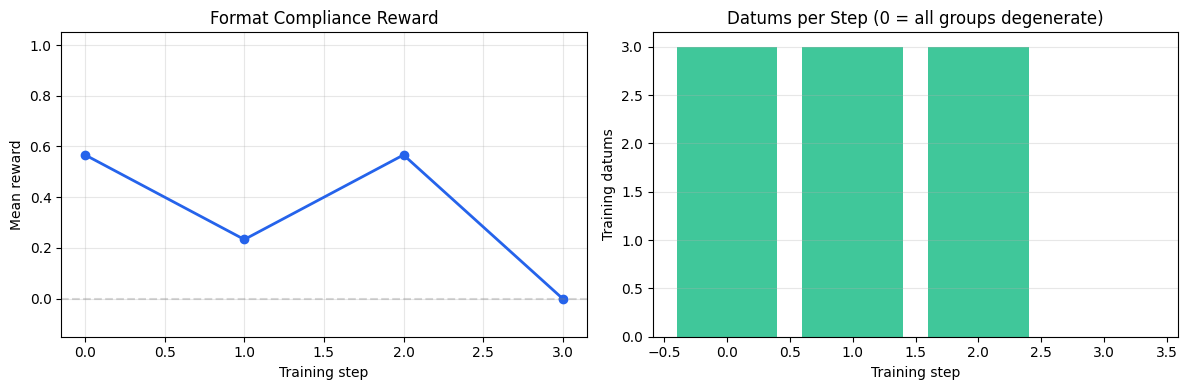

In [8]:
import matplotlib.pyplot as plt

steps = [m["step"] for m in metrics_history]
rewards = [m["reward"] for m in metrics_history]
n_datums = [m["n_datums"] for m in metrics_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(steps, rewards, marker="o", linewidth=2, color="#2563eb")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean reward")
ax1.set_title("Format Compliance Reward")
ax1.set_ylim(-0.15, 1.05)
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax1.grid(True, alpha=0.3)

ax2.bar(steps, n_datums, color="#10b981", alpha=0.8)
ax2.set_xlabel("Training step")
ax2.set_ylabel("Training datums")
ax2.set_title("Datums per Step (0 = all groups degenerate)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [9]:
eval_client = training_client.save_weights_and_get_sampling_client(name="format-env-final")

for prompt_text, format_type in EVAL_PROBLEMS:
    messages = [{"role": "user", "content": prompt_text}]
    model_input = renderer.build_generation_prompt(messages)
    result = eval_client.sample(
        prompt=model_input,
        num_samples=1,
        sampling_params=tinker.SamplingParams(
            max_tokens=MAX_TOKENS, temperature=0.5, stop=renderer.get_stop_sequences()
        ),
    ).result()

    parsed_msg, _ = renderer.parse_response(result.sequences[0].tokens)
    content = get_text_content(parsed_msg)
    checker = FORMAT_CHECKERS[format_type]
    passed = checker(content)
    status = "PASS" if passed else "FAIL"

    print(f"[{status}] Format: {format_type}")
    print(f"  Prompt: {prompt_text}")
    print(f"  Response: {content[:200]}...")
    print()

[FAIL] Format: json
  Prompt: Describe machine learning in JSON format with keys: definition, types, applications.
  Response: Thinking Process:

1.  **Analyze the Request:**
    *   Task: Describe machine learning in JSON format with keys: definition, types, applications.
    *   Format: JSON format.
    *   Keys: definition...



[PASS] Format: numbered_list
  Prompt: List 3 ways to reduce waste. Use a numbered list.
  Response: Thinking Process:

1.  **Analyze the Request:**
    *   Task: List 3 ways to reduce waste.
    *   Format: Use a numbered list.
    *   Quantity: 3 ways.
    *   Constraint: None specified beyond that...



[FAIL] Format: haiku
  Prompt: Write a haiku about snow.
  Response: Thinking Process:

1.  **Analyze the request:** "Write a haiku about snow."
2.  **Determine the task:** Write a haiku (5-7-5 syllables) about snow.
3.  **Draft:**
    *   Option 1: White flakes fall d...



## The pattern for any new task

To bring your own task to the cookbook's RL infrastructure, you need three things:

1. **Subclass `ProblemEnv`** -- implement `get_question()`, `check_answer()`, `check_format()`, `get_reference_answer()`. For multi-step tasks (tool use, multi-turn dialogue), implement `Env` directly instead.
2. **Create an `RLDataset`** -- its `get_batch()` returns `ProblemGroupBuilder`s that wrap your env. Use `functools.partial` for the `env_thunk`.
3. **Use the standard pipeline** -- `do_group_rollout_and_filter_constant_reward` + `compute_advantages` + `assemble_training_data` + `forward_backward`.

For production use, `tinker_cookbook.rl.train` wraps this loop with logging, checkpointing, and periodic evaluation.

## Going further

- **Multi-step environments**: Implement `Env` directly for tasks where the agent takes multiple actions (tool use, search, games). See `tinker_cookbook/recipes/code_rl/` for an example with sandbox execution.
- **Production recipes**: `tinker_cookbook/recipes/math_rl/` and `tinker_cookbook/recipes/code_rl/` show full-featured training setups with dataset loading, grading, and configuration.
- **Custom group rewards**: Override `EnvGroupBuilder.compute_group_rewards()` for pairwise or multi-agent reward functions.
- **Full docs**: [RL Environments](../docs/rl/rl-envs.mdx) covers the complete Env lifecycle, builder patterns, and advanced features.